In [1]:
# SPLIT TRAIN/TEST SETS

import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv("../data/processed/preprocessed_texts.csv")

y = df["label"]
X_stopwords = df["text_stopwords"]

X_train, X_test,y_train, y_test =train_test_split(X_stopwords,y,test_size=0.2,random_state=42,stratify=y)

print("train size:",len(X_train), "test size:",len(X_test))
print(y_train.value_counts(normalize= True))

train size: 3876 test size: 970
label
neutral     0.594169
positive    0.281218
negative    0.124613
Name: proportion, dtype: float64


In [2]:
# REUSABLE EVALUATION FUNCTION (defined early so every later cell can call it)

from pathlib import Path
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

OUTPUT_DIR = Path("../results/task3_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def evaluate(y_true, y_pred, title=""):
    print(title)
    print(classification_report(y_true, y_pred))
    ConfusionMatrixDisplay.from_predictions(y_true, y_pred)
    plt.title(title)
    # save a PNG named after the title (spaces/punct -> underscores)
    fname = "".join(c if c.isalnum() else "_" for c in title).strip("_") or "confusion_matrix"
    plt.savefig(OUTPUT_DIR / f"{fname}.png", dpi=300, bbox_inches="tight")
    plt.show()

In [3]:
# VECTORIZING ( with bag of wordss)

from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()
X_train_bow = vectorizer.fit_transform(X_train)
X_test_bow = vectorizer.transform(X_test)


# SPARSITY of the Matrix

print("matrix shape:", X_train_bow.shape)
print("total cells:", X_train_bow.shape[0] * X_train_bow.shape[1])
print("non-zero cells:", X_train_bow.nnz)
print("density: %.4f%%" % (100 * X_train_bow.nnz / (X_train_bow.shape[0]*X_train_bow.shape[1])))


matrix shape: (3876, 8733)
total cells: 33849108
non-zero cells: 46313
density: 0.1368%


In [4]:
# NAIVE BAYES model ( bag of words )

from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()

model.fit(X_train_bow,y_train)       # learns from training. estimate priors
y_pred = model.predict(X_test_bow)   #outputs predicted label for each row

print(y_pred[:20])
print(len(y_pred))

['neutral' 'neutral' 'neutral' 'positive' 'negative' 'neutral' 'neutral'
 'negative' 'negative' 'neutral' 'neutral' 'neutral' 'neutral' 'neutral'
 'positive' 'neutral' 'neutral' 'neutral' 'neutral' 'neutral']
970


Naive Bayes + BoW
              precision    recall  f1-score   support

    negative       0.69      0.53      0.60       121
     neutral       0.77      0.84      0.81       576
    positive       0.60      0.55      0.57       273

    accuracy                           0.72       970
   macro avg       0.69      0.64      0.66       970
weighted avg       0.71      0.72      0.71       970



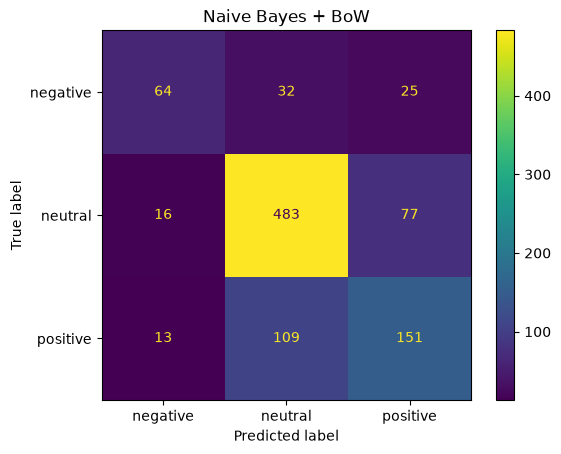

In [5]:
# EVALUATION METRICS (Naive Bayes + BoW)

evaluate(y_test, y_pred, "Naive Bayes + BoW")

In [6]:
# FOR THE REPORT
# The model's errors are overwhelmingly confusions with the neutral majority class
# rather than polarity flips, which means the difficulty is separating weak sentiment
# from neutral reporting — not telling positive from negative.

In [7]:
# VECTORIZING (TF-IDF)

from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# SPARSITY of the Matrix

print("matrix shape:", X_train_bow.shape)
print("total cells:", X_train_bow.shape[0] * X_train_bow.shape[1])
print("non-zero cells:", X_train_bow.nnz)
print("density: %.4f%%" % (100 * X_train_bow.nnz / (X_train_bow.shape[0]*X_train_bow.shape[1])))


matrix shape: (3876, 8733)
total cells: 33849108
non-zero cells: 46313
density: 0.1368%


Naive Bayes + TF-IDF
              precision    recall  f1-score   support

    negative       0.88      0.06      0.11       121
     neutral       0.69      0.97      0.81       576
    positive       0.61      0.33      0.43       273

    accuracy                           0.68       970
   macro avg       0.73      0.45      0.45       970
weighted avg       0.69      0.68      0.61       970



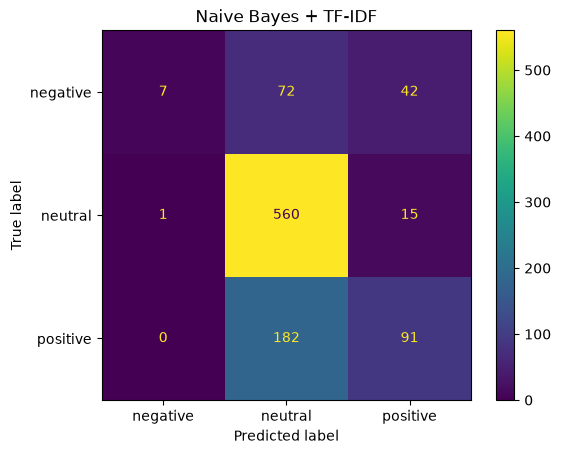

In [8]:
# Naive Bayes  ( TF-IDF )

model_tfidf = MultinomialNB()
model_tfidf.fit(X_train_tfidf, y_train)
y_pred_tfidf = model_tfidf.predict(X_test_tfidf)

evaluate(y_test, y_pred_tfidf, "Naive Bayes + TF-IDF")


In [9]:
# REPORT
# TF-IDF down-weighting flattened the word-likelihood signal
# that Multinomial Naive Bayes relies on, so predictions defaulted to the
# high-prior neutral class — improving neutral recall but collapsing minority-class
# recall and lowering macro-F1 from 0.66 to 0.45.

# "Better" representation (TF-IDF) ≠ better results. It depends on the classifier. TF-IDF + Multinomial NB is a known poor pairing precisely because of this prior-domination effect.
# And critically — accuracy (0.68) barely moved, but macro-F1 cratered (0.45).
# If you'd only reported accuracy, you'd think TF-IDF was "fine."
# Macro-F1 and the confusion matrix reveal the model effectively gave up on negatives.
# This is your strongest evidence yet for why macro-F1 is the honest metric.

NB + BoW (uniform prior)
              precision    recall  f1-score   support

    negative       0.53      0.63      0.57       121
     neutral       0.79      0.75      0.77       576
    positive       0.56      0.58      0.57       273

    accuracy                           0.68       970
   macro avg       0.63      0.65      0.64       970
weighted avg       0.69      0.68      0.69       970



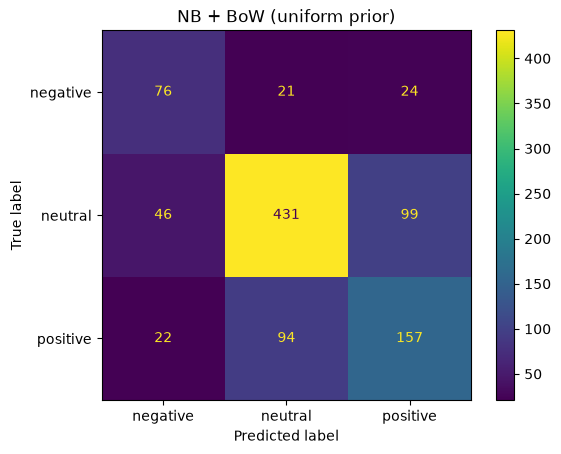

In [10]:
#  Handling class imbalance (uniform prior)

model_fix = MultinomialNB(fit_prior=False)

model_fix.fit(X_train_bow,y_train)
y_pred_fix = model_fix.predict(X_test_bow)
evaluate(y_test, y_pred_fix, "NB + BoW (uniform prior)")